# Exploratory Data Analysis — AI Book Librarian

Run `python -m src.data_prep` first so `data/processed/training_table.parquet` exists.
This notebook documents the EDA referenced in the project documentation (Section 2A).

In [10]:
import sys, pathlib
# make `import src` work whether the kernel starts in the repo root or in notebooks/
_root = pathlib.Path.cwd()
if not (_root / 'src').exists() and (_root.parent / 'src').exists():
    _root = _root.parent
sys.path.insert(0, str(_root))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from src import config as cfg
sns.set_theme(style='whitegrid')

df = pd.read_parquet(cfg.TRAINING_PARQUET)
print(df.shape)
df.head()

(4000, 36)


,Unnamed: 0,src_book_id,cover_image_uri,title,description,format,publication_date,authorlink,authors,num_pages,...,genre_historical_fiction,genre_nonfiction,genre_mystery,genre_romance,genre_young_adult,genre_contemporary,genre_science_fiction,genre_historical,genre_thriller,genre_science_fiction_fantasy
0,0,1,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Half-Blood Prince,"It is the middle of the summer, but there is a...","['652 pages, Paperback']","['First published July 16, 2005']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,652.0,...,0,0,0,0,1,0,0,0,0,0
1,1,2,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Order of the Phoenix,Harry Potter is about to start his fifth year ...,"['912 pages, Paperback']","['First published June 21, 2003']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,912.0,...,0,0,0,0,1,0,0,0,0,0
2,2,3,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Sorcerer's Stone,Harry Potter has no idea how famous he is. Tha...,"['309 pages, Hardcover']","['First published June 26, 1997']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,309.0,...,0,0,0,0,1,0,0,0,0,0
3,3,5,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Prisoner of Azkaban,"Harry Potter, along with his best friends, Ron...","['435 pages, Mass Market Paperback']","['First published July 8, 1999']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,435.0,...,0,0,0,0,1,0,0,0,0,0
4,4,6,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Goblet of Fire,It is the summer holidays and soon Harry Potte...,"['734 pages, Paperback']","['First published July 8, 2000']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,734.0,...,0,0,0,0,1,0,0,0,0,0


## 1. Schema, types and missingness

In [11]:
df.info()
miss = df.isna().mean().sort_values(ascending=False)
miss[miss > 0].head(20)

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     4000 non-null   int64  
 1   src_book_id                    4000 non-null   str    
 2   cover_image_uri                4000 non-null   str    
 3   title                          4000 non-null   str    
 4   description                    4000 non-null   str    
 5   format                         4000 non-null   str    
 6   publication_date               4000 non-null   str    
 7   authorlink                     4000 non-null   str    
 8   authors                        4000 non-null   str    
 9   num_pages                      3981 non-null   float64
 10  genres                         4000 non-null   str    
 11  ratings_count                  4000 non-null   int64  
 12  text_reviews_count             4000 non-null   int64  
 13 

sentiment_compound    0.10275
publication_year      0.01075
num_pages             0.00475
dtype: float64

## 2. Target distribution — average_rating

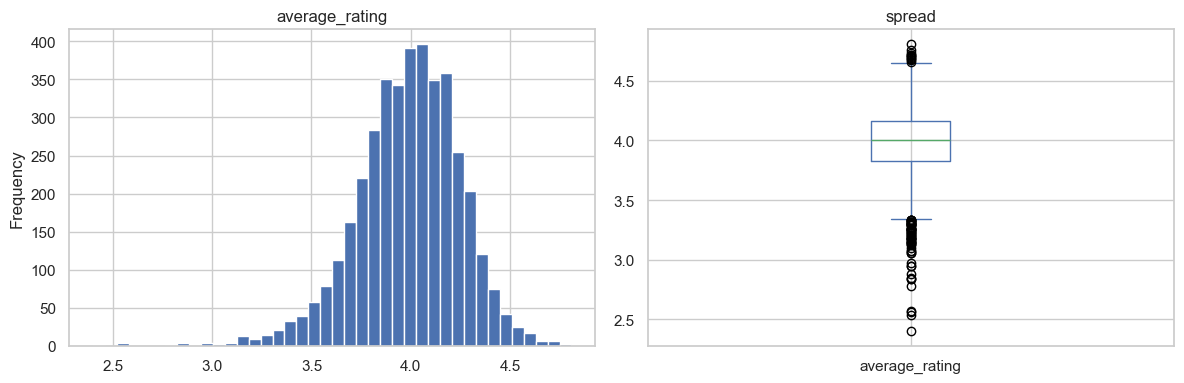

count    4000.000000
mean        3.985100
std         0.259734
min         2.400000
25%         3.830000
50%         4.005000
75%         4.160000
max         4.810000
Name: average_rating, dtype: float64

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["average_rating"].plot.hist(bins=40, ax=ax[0]); ax[0].set_title("average_rating")
df["average_rating"].plot.box(ax=ax[1]); ax[1].set_title("spread")
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / "target_distribution.png", dpi=120); plt.show()
df["average_rating"].describe()

**Finding (fill in):** ratings cluster tightly around ~3.9–4.0. A narrow target means a
naive 'predict the mean' baseline is already hard to beat — note its RMSE for comparison.

In [13]:
baseline_rmse = np.sqrt(((df["average_rating"] - df["average_rating"].mean())**2).mean())
print("Mean-baseline RMSE:", round(baseline_rmse, 3))

Mean-baseline RMSE: 0.26


## 3. Numeric features & skew (ratings_count, num_pages)

In [14]:
num = ["num_pages", "ratings_count", "text_reviews_count", "publication_year"]
df[num].describe()

,num_pages,ratings_count,text_reviews_count,publication_year
count,3981.000000,4.000000e+03,4000.000000,3957.000000
mean,384.340116,1.185522e+05,4433.231250,1975.124084
std,263.701004,4.040048e+05,10565.172846,51.203257
min,1.000000,1.300000e+01,0.000000,1513.000000
25%,240.000000,1.061600e+04,585.000000,1969.000000
50%,336.000000,2.945150e+04,1505.500000,1992.000000
75%,459.000000,7.994425e+04,3833.500000,2001.000000
max,6576.000000,1.011625e+07,163493.000000,2015.000000


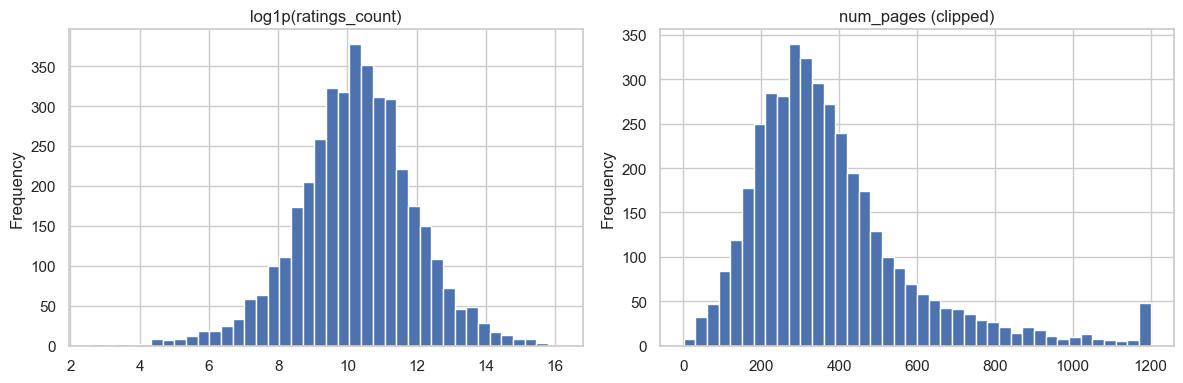

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
np.log1p(df["ratings_count"].dropna()).plot.hist(bins=40, ax=ax[0]); ax[0].set_title("log1p(ratings_count)")
df["num_pages"].clip(upper=1200).plot.hist(bins=40, ax=ax[1]); ax[1].set_title("num_pages (clipped)")
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / "feature_distributions.png", dpi=120); plt.show()

## 4. Correlation with the target

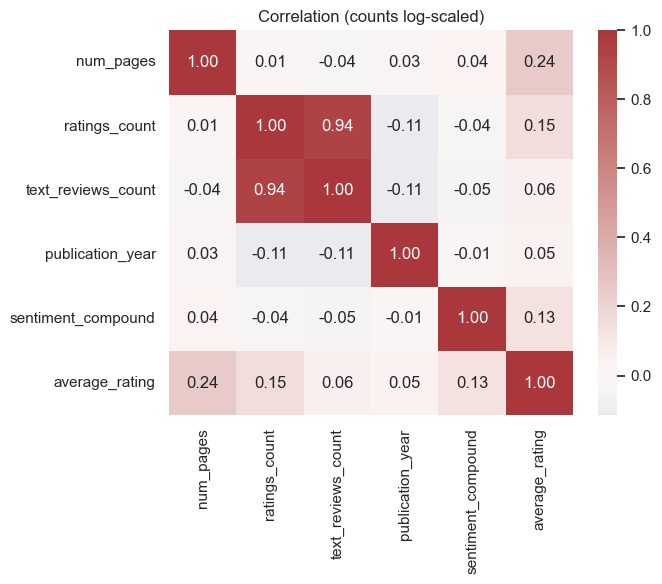

In [16]:
cols = [c for c in num + ["sentiment_compound", "average_rating"] if c in df.columns]
corr = df[cols].apply(lambda s: np.log1p(s) if s.name in ("ratings_count","text_reviews_count") else s).corr()
plt.figure(figsize=(7, 6)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation (counts log-scaled)"); plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / "correlation.png", dpi=120); plt.show()

## 5. NLP-derived sentiment vs. rating

books with sentiment: 3589


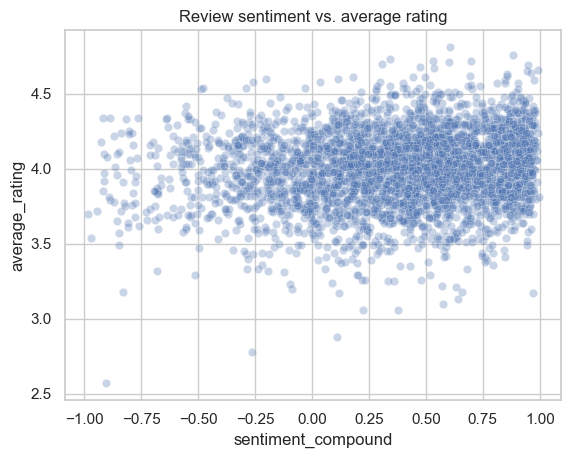

corr: 0.132


In [17]:
sub = df.dropna(subset=["sentiment_compound"])
print("books with sentiment:", len(sub))
if len(sub):
    sns.scatterplot(data=sub, x="sentiment_compound", y="average_rating", alpha=0.3)
    plt.title("Review sentiment vs. average rating")
    plt.savefig(cfg.FIGURES_DIR / "sentiment_vs_rating.png", dpi=120); plt.show()
    print("corr:", round(sub["sentiment_compound"].corr(sub["average_rating"]), 3))

## 6. Genres / categories coverage

In [23]:
genre_cols = [c for c in df.columns if c.startswith("genre_")and c != "genre_str"]
df[genre_cols].sum().sort_values(ascending=False)

genre_fiction                    3224
genre_classics                   1418
genre_fantasy                    1169
genre_literature                 1023
genre_novels                      913
genre_historical_fiction          818
genre_nonfiction                  710
genre_mystery                     616
genre_romance                     566
genre_young_adult                 537
genre_contemporary                534
genre_science_fiction             489
genre_historical                  463
genre_thriller                    447
genre_science_fiction_fantasy     398
dtype: int64

## 7. Key findings (write up)

- Target is narrow → low achievable R²; report RMSE vs. the mean baseline.
- `ratings_count` is extremely skewed → log-transform (done in `train.py`).
- Sentiment coverage is partial (only books matched to a review) → median-imputed in the pipeline.
- Strongest / weakest correlates: _fill from the heatmap above_.